In [ ]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# Load data
df = pd.read_csv('heart_diseases.csv')
print(f"Data loaded successfully. Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

Saving heart_diseases.csv to heart_diseases.csv


In [ ]:
# Display dataset info
print("\nDataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())

In [ ]:
# Prepare features - handle categorical data
df_processed = df.copy()

# Handle missing values
df_processed = df_processed.dropna(subset=['Age', 'Sex', 'BloodPressure', 'Cholesterol', 'MaxHR'])

# Encode categorical variables if needed
if 'Sex' in df_processed.columns and df_processed['Sex'].dtype == 'object':
    sex_mapping = {'M': 1, 'F': 0}
    df_processed['Sex'] = df_processed['Sex'].replace(sex_mapping)

features = ['Age', 'Sex', 'BloodPressure', 'Cholesterol', 'MaxHR']
X = df_processed[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data prepared with features: {features}")
print(f"Processed data shape: {X_scaled.shape}")
df_processed.head()

Data loaded with features: ['Age', 'Sex', 'BloodPressure', 'Cholesterol', 'MaxHR']


,Age,Sex,BloodPressure,Cholesterol,MaxHR
0,68,0,147,175,194
1,58,0,118,221,169
2,44,0,176,197,155
3,72,0,126,343,182
4,37,0,164,347,157


In [ ]:
n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, random_state=56, n_init='auto')
km_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=1.2, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=n_clusters, random_state=56)
gmm_labels = gmm.fit_predict(X_scaled)

print("Clustering completed.")

Clustering completed.


In [ ]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

print("PCA and t-SNE reduction finished.")

PCA and t-SNE reduction finished.


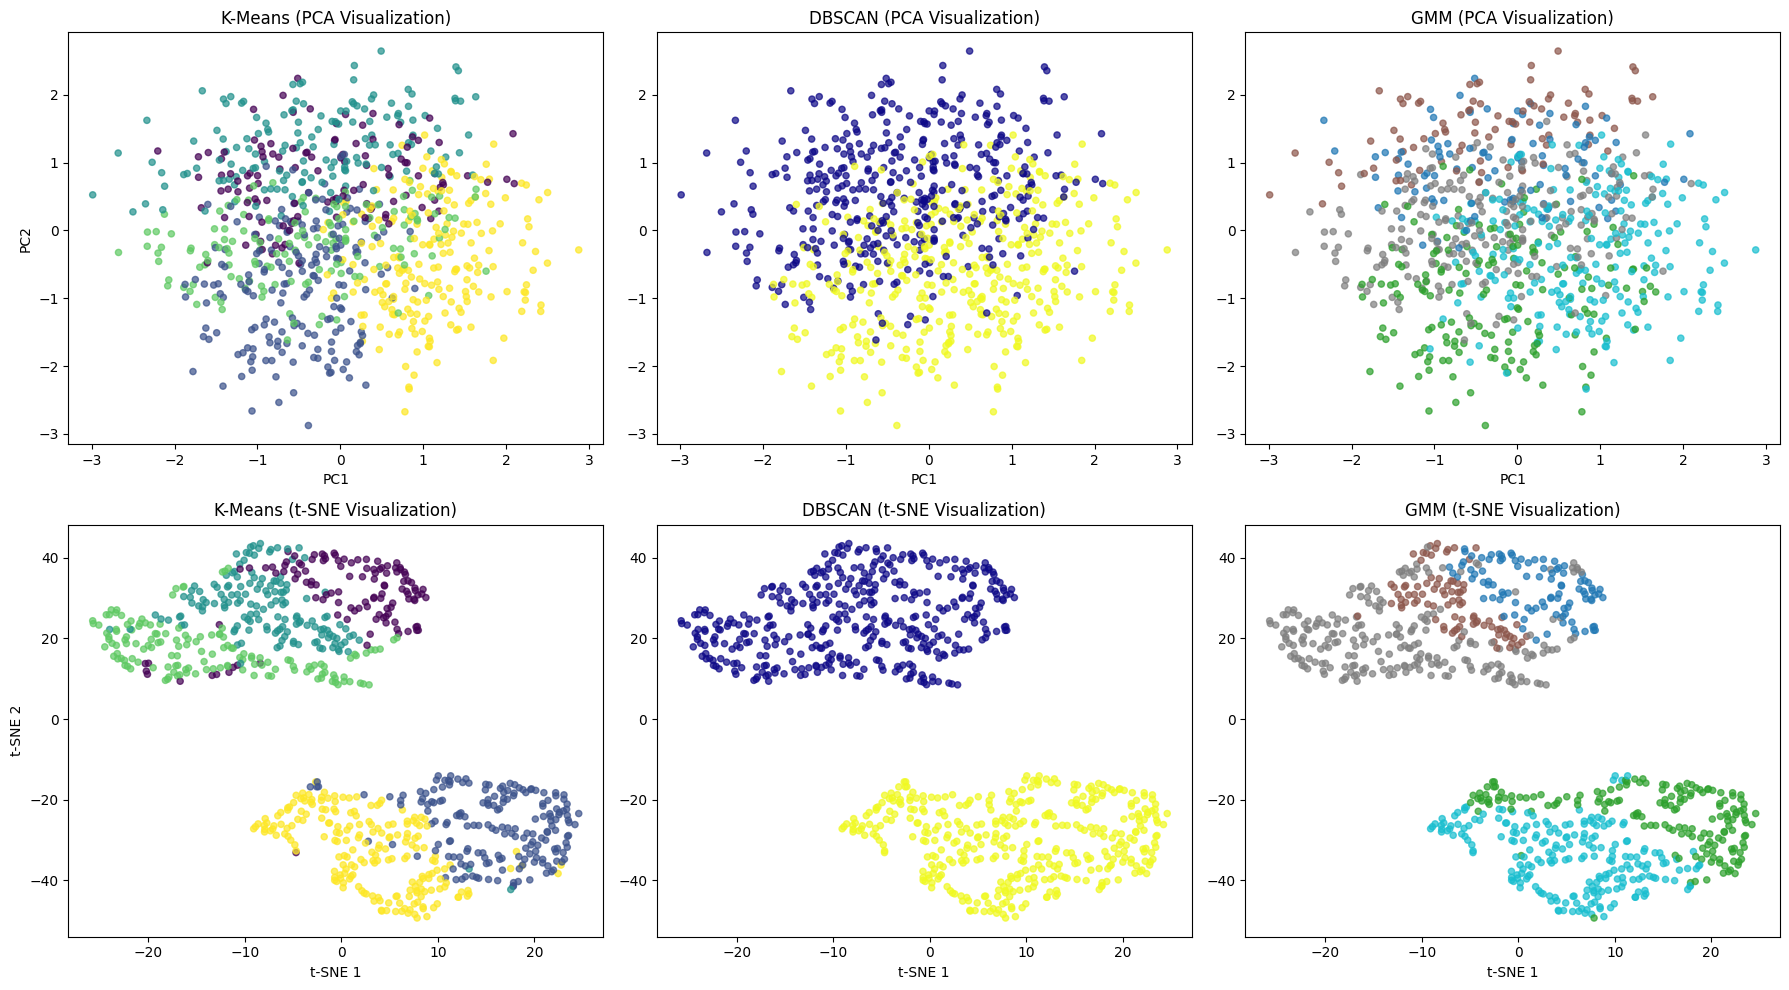

In [ ]:
plt.figure(figsize=(18, 10))

# PCA Visualization
plt.subplot(2, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap='viridis', s=20, alpha=0.7)
plt.title('K-Means (PCA Visualization)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.subplot(2, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='plasma', s=20, alpha=0.7)
plt.title('DBSCAN (PCA Visualization)')
plt.xlabel('PC1')

plt.subplot(2, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='tab10', s=20, alpha=0.7)
plt.title('GMM (PCA Visualization)')
plt.xlabel('PC1')

# t-SNE Visualization
plt.subplot(2, 3, 4)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_labels, cmap='viridis', s=20, alpha=0.7)
plt.title('K-Means (t-SNE Visualization)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

plt.subplot(2, 3, 5)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=db_labels, cmap='plasma', s=20, alpha=0.7)
plt.title('DBSCAN (t-SNE Visualization)')
plt.xlabel('t-SNE 1')

plt.subplot(2, 3, 6)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=gmm_labels, cmap='tab10', s=20, alpha=0.7)
plt.title('GMM (t-SNE Visualization)')
plt.xlabel('t-SNE 1')

plt.tight_layout()
plt.show()